<a href="https://colab.research.google.com/github/dokunoale/chagas/blob/feature%2FLSTM/notebooks/2.CONV1D%20_%2B_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modello LSTM con livelli convolutivi

## Download delle dipendenze e preparazione dell'environment

Scarichiamo le funzioni per il caricamento del dataset, installiamo le dipendenze, importiamo le librerie necessarie, e scarichiamo il dataset da remoto.

In [ ]:
!git clone -b fix/spectrogram https://github.com/dokunoale/chagas.git
!pip install -r chagas/requirements.txt

# Download the dataset
import gdown

url = "https://drive.google.com/file/d/1vK_gMI36xjdtiJjMBV7dKHurIExQs4hC/view?usp=drive_link"
gdown.download(url, "dataset.zip", quiet=False, fuzzy=True)
!unzip -q /content/dataset.zip -d chagas/data/

In [ ]:
import sys
sys.path.append("/content/chagas/src")

import os

import tensorflow as tf
from tensorflow.keras.layers import Layer
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.metrics import AUC

import numpy as np
from sklearn.model_selection import train_test_split
from scipy.signal import iirnotch, butter, filtfilt

from preprocessing.tf_dataset_loader import load_dataset, concatenate_and_shuffle
from models.layers import LogSpectrogram

Il dataset analizzato in questo notebook è diviso in *train*, *validation* e *test*; ciascuno diviso tra positivi e negativi.

L'opzione `more_info` permette di scaricare tutte le label associate a ogni campione oltre alla label per la classificazione binaria:
- `Age`, età del paziente
- `Sex`, sesso del paziente
- `Source`, dataset originale del campione

In [ ]:
# Carichiamo il dataset
data_path = "/content/chagas/data/big_splitted_dataset/"

X_train, y_train = concatenate_and_shuffle(
    load_dataset(data_path + "train/positives"),
    load_dataset(data_path + "train/negatives"))

X_val, y_val = concatenate_and_shuffle(
    load_dataset(data_path + "val/positives"),
    load_dataset(data_path + "val/negatives"))

X_test, y_test_info = concatenate_and_shuffle(
    load_dataset(data_path + "test/positives", more_info=True),
    load_dataset(data_path + "test/negatives", more_info=True))

y_test = [info['chagas'] for info in y_test_info]

## Preprocessing

I segnali ECG del dataset provengono da rilevazioni reali. In particolare i dati provenienti dal dataset *SaMi-Trop* non sono preprocessati, e presentano rumore e distorsioni.

Per ottenere dei dati simili, pur proveniendo da fonti differenti (si suppone che i dati provengano da fonti diverse anche all'interno dei signoli dataset che compongono quello proposto).

Per fare ciò applichiamo vari livelli di preprocessing:
1. Normalizzazione del segnale
2. *Noise Reduction*
3. Spettrogramma Logaritmico


### Noise reduction

> In primo luogo, il rumore introdotto dalla componente elettrica a **60** Hz viene rimosso utilizzando un filtro notch IIR, applicato anche dopo l'inversione temporale per evitare distorsioni di fase. Infine, la linea di base del segnale viene normalizzata applicando un *third order high-pass Butterworth* filter con frequenza di taglio di **5.** Hz.

> [ECG biometric recognition: Permanence analysis of QRS signals for 24 hours continuous authentication](https://ieeexplore.ieee.org/document/6707790)

> <u> J. Proakis and D. Manolakis, Digital signal processing. Pearson
Prentice Hall, 2007. </u>

L'implementazione è presentata in due versioni: delle quali la più indicata all'applicazione è `filtfilt_noise_reduction`, in quanto rivolve il problema mensionato in precedenza sulle distorsioni di fase.
L'uso di questa tecnica migliora notevolmente la stabilità del modello in fase di training.

In [ ]:
import numpy as np
from scipy.signal import iirnotch, butter, lfilter, filtfilt

def filtfilt_noise_reduction(inputs, fs, iir_freq=50.0, butterworth_cutoff=0.5, lowpass_cutoff=None):
    """
    Applica filtri IIR e Butterworth per la riduzione del rumore su un batch di segnali ECG.

    Parametri:
    - inputs: array numpy di forma (batch_size, time_steps, channels)
    - fs: frequenza di campionamento (es: 400 Hz)
    - iir_freq: frequenza di taglio per il filtro notch (default 50.0 Hz)
    - butterworth_cutoff: frequenza di taglio per il filtro high-pass (default 0.5 Hz)
    - lowpass_cutoff: frequenza di taglio per un filtro low-pass opzionale (default None)

    Ritorna:
    - Un array numpy filtrato della stessa forma di inputs.
    """

    # Design notch filter (IIR)
    Q = 30.0
    b_notch, a_notch = iirnotch(w0=iir_freq, Q=Q, fs=fs)

    # Design high-pass Butterworth filter
    b_high, a_high = butter(N=3, Wn=butterworth_cutoff, btype='highpass', fs=fs)

    # Design optional low-pass filter
    if lowpass_cutoff is not None:
        b_low, a_low = butter(N=3, Wn=lowpass_cutoff, btype='lowpass', fs=fs)
    else:
        b_low, a_low = None, None

    def _apply_filters(batch_np):
        # Applica i filtri a ciascun segnale nel batch e a ciascun canale
        filtered_batch = []
        for sample in batch_np:  # sample shape: (time_steps, channels)
            channels = []
            for i in range(sample.shape[1]):
                x = sample[:, i]
                x = filtfilt(b_notch, a_notch, x)
                x = filtfilt(b_high, a_high, x)
                if b_low is not None:
                    x = filtfilt(b_low, a_low, x)
                channels.append(x)
            # Ricostruisci un array (time_steps, channels)
            filtered_sample = np.stack(channels, axis=-1)
            filtered_batch.append(filtered_sample)
        return np.stack(filtered_batch, axis=0).astype(np.float32)

    # Applica i filtri a tutto il batch
    filtered_inputs = _apply_filters(inputs)

    return filtered_inputs

In [ ]:
# Preprocessing
X_train = lfilter_noise_reduction(X_train, fs=400, iir_freq=60.0, butterworth_cutoff=5., lowpass_cutoff=60.)
X_val = lfilter_noise_reduction(X_val, fs=400, iir_freq=60.0, butterworth_cutoff=5., lowpass_cutoff=60.)
X_test = lfilter_noise_reduction(X_test, fs=400, iir_freq=60.0, butterworth_cutoff=5., lowpass_cutoff=60.)

X_train = lfilter_noise_reduction(X_train, fs=400, iir_freq=60.0, butterworth_cutoff=5., lowpass_cutoff=60.)
X_val = lfilter_noise_reduction(X_val, fs=400, iir_freq=60.0, butterworth_cutoff=5., lowpass_cutoff=60.)
X_test = lfilter_noise_reduction(X_test, fs=400, iir_freq=60.0, butterworth_cutoff=5., lowpass_cutoff=60.)

### Logarithmic Spectrogram

In [ ]:
import tensorflow as tf
import keras

@keras.saving.register_keras_serializable()
class LightLogSpectrogram(tf.keras.layers.Layer):
    def __init__(self, frame_length=64, frame_step=32, fft_length=256,
                 scale=128.0, num_log_bins=64, **kwargs):
        super(LightLogSpectrogram, self).__init__(**kwargs)
        self.frame_length = frame_length
        self.frame_step = frame_step
        self.fft_length = fft_length
        self.scale = scale
        self.num_log_bins = num_log_bins

    def build(self, input_shape):
        # Calcola indici logaritmici una sola volta
        freq_bins = self.fft_length // 2 + 1
        linear_bins = tf.range(freq_bins, dtype=tf.float32)
        log_indices = tf.exp(
            tf.linspace(
                tf.math.log(1.0),
                tf.math.log(tf.cast(freq_bins, tf.float32)),
                self.num_log_bins
            )
        ) - 1.0
        log_indices = tf.clip_by_value(tf.cast(tf.round(log_indices), tf.int32), 0, freq_bins - 1)
        self.log_indices = tf.constant(log_indices)

    def call(self, inputs):
        spectrograms = []
        for i in range(inputs.shape[-1]):  # Per ogni lead
            signal = inputs[..., i]

            # STFT
            stft = tf.signal.stft(
                signal,
                frame_length=self.frame_length,
                frame_step=self.frame_step,
                fft_length=self.fft_length,
                window_fn=tf.signal.hann_window,
                pad_end=True
            )
            spec = tf.abs(stft)

            # log1p scaling
            spec = tf.math.log1p(self.scale * spec)

            # Indicizzazione logaritmica
            spec = tf.gather(spec, self.log_indices, axis=-1)

            spectrograms.append(spec)

        return tf.stack(spectrograms, axis=-1)

    def compute_output_shape(self, input_shape):
        time_dim = (input_shape[1] + self.frame_step - 1) // self.frame_step if input_shape[1] else None
        return (input_shape[0], time_dim, self.num_log_bins, input_shape[-1])


## Definizione del modello e training

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, Conv1D, LSTM, MaxPooling1D, Flatten, Dropout, Dense, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

In [ ]:
model = Sequential()
model.add(Input(shape=(2800, 12)))

# compressione moderata con due livelli convolutivi
model.add(Conv1D(16, kernel_size=7, activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=4))

model.add(Conv1D(32, kernel_size=5, activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=4))

# livello LSTM
model.add(Bidirectional(LSTM(16, return_sequences=False)))
model.add(Dropout(0.5))

# livelli Dense per la classificazione
model.add(Dense(16, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

In [ ]:
# Compilazione del modello
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', AUC(name='auc')]
)

model.summary()

# Callback: early stopping e salvataggio del modello migliore
early_stop = EarlyStopping(monitor='val_auc', patience=6, mode='max', restore_best_weights=True)
checkpoint = ModelCheckpoint("best_model.keras", monitor='val_auc', mode='max', save_best_only=True)

callbacks = [early_stop, checkpoint]

# Training
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=30,
    callbacks=callbacks
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 2800, 16)       │         1,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2800, 16)       │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 700, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 700, 32)        │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 700, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 175, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 32)             │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,961 (42.82 KB)

 Trainable params: 10,865 (42.44 KB)

 Non-trainable params: 96 (384.00 B)

Epoch 1/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 15s 27ms/step - accuracy: 0.5280 - auc: 0.5439 - loss: 0.7005 - val_accuracy: 0.5446 - val_auc: 0.6356 - val_loss: 0.6819
Epoch 2/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.6131 - auc: 0.6584 - loss: 0.6563 - val_accuracy: 0.6560 - val_auc: 0.6974 - val_loss: 0.6355
Epoch 3/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.6476 - auc: 0.7026 - loss: 0.6312 - val_accuracy: 0.6774 - val_auc: 0.7276 - val_loss: 0.6163
Epoch 4/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.6601 - auc: 0.7155 - loss: 0.6178 - val_accuracy: 0.6765 - val_auc: 0.7276 - val_loss: 0.6105
Epoch 5/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.6649 - auc: 0.7118 - loss: 0.6220 - val_accuracy: 0.6595 - val_auc: 0.7206 - val_loss: 0.6360
Epoch 6/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.6684 - auc: 0.7292 - loss: 0.6147 - val_accuracy: 0.6613 - val_auc: 0.7114 - val_loss: 0.6204
Epoch 7/50
262/262 ━━━━━━━━━━━━

## Analisi delle performace

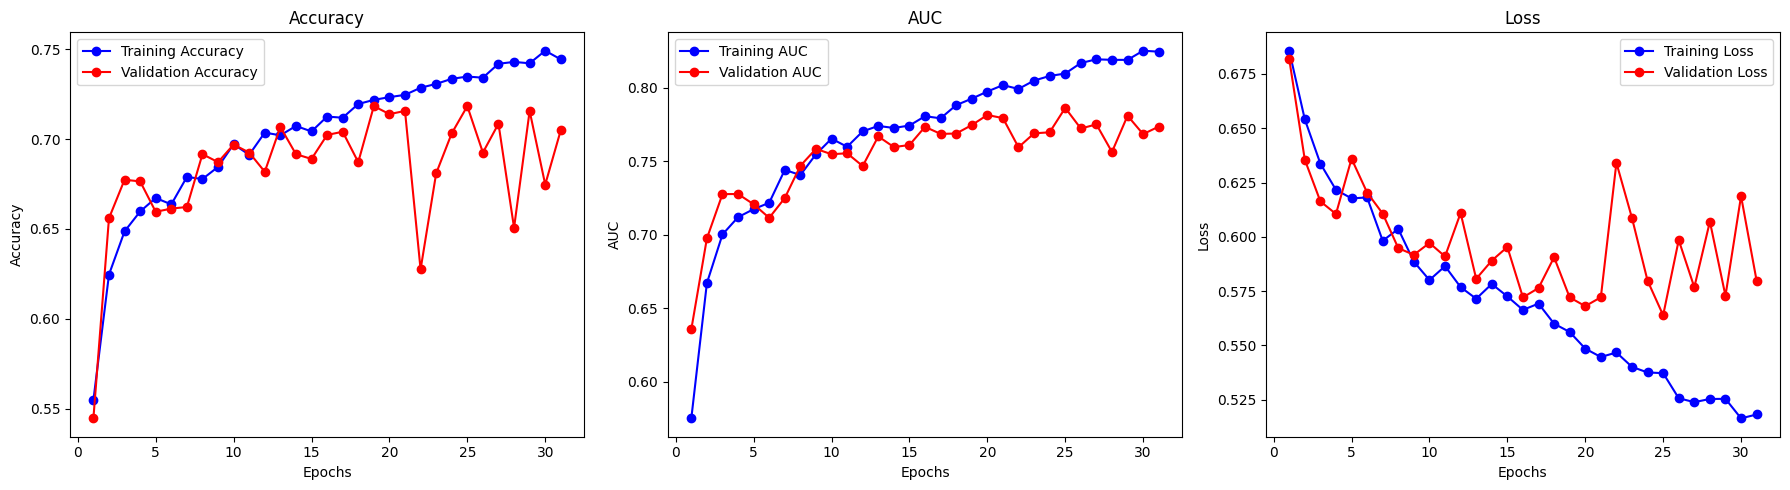

In [ ]:
def plot_training_metrics(history):
    """
    Plotta Accuracy, AUC e Loss per training e validation da un oggetto history di Keras.

    Args:
        history: History object restituito da model.fit()
    """
    acc = history.history.get('accuracy')
    val_acc = history.history.get('val_accuracy')
    auc = history.history.get('auc')
    val_auc = history.history.get('val_auc')
    loss = history.history.get('loss')
    val_loss = history.history.get('val_loss')
    epochs = range(1, len(acc) + 1) if acc else range(1, len(loss) + 1)

    plt.figure(figsize=(18, 5))

    # Plot Accuracy
    if acc and val_acc:
        plt.subplot(1, 3, 1)
        plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
        plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
        plt.title('Accuracy')
        plt.xlabel('Epochs')
        plt.ylabel('Accuracy')
        plt.legend()

    # Plot AUC
    if auc and val_auc:
        plt.subplot(1, 3, 2)
        plt.plot(epochs, auc, 'bo-', label='Training AUC')
        plt.plot(epochs, val_auc, 'ro-', label='Validation AUC')
        plt.title('AUC')
        plt.xlabel('Epochs')
        plt.ylabel('AUC')
        plt.legend()

    # Plot Loss
    if loss and val_loss:
        plt.subplot(1, 3, 3)
        plt.plot(epochs, loss, 'bo-', label='Training Loss')
        plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
        plt.title('Loss')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()

    plt.tight_layout()
    plt.show()

plot_training_metrics(history)